In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Set a clean visual style for our charts
sns.set_theme(style="darkgrid")
# Optional: Set a custom color palette using Netflix Red and Dark Grey
netflix_colors = ["#b20710", "#221f1f"]
sns.set_palette(sns.color_palette(netflix_colors))
df=pd.read_csv('netflix_user_behavior_dataset.csv')

In [3]:
#no of rows and columns
df.shape

(50000, 20)

In [4]:
# data types of each column
df.dtypes

user_id                       object
age                            int64
gender                        object
country                       object
account_age_months             int64
subscription_type             object
monthly_fee                  float64
payment_method                object
primary_device                object
devices_used                   int64
favorite_genre                object
avg_watch_time_minutes         int64
watch_sessions_per_week        int64
binge_watch_sessions           int64
completion_rate                int64
rating_given                 float64
content_interactions           int64
recommendation_click_rate      int64
days_since_last_login          int64
churned                       object
dtype: object

In [5]:
#statistical summary of the dataset
df.describe()

,age,account_age_months,monthly_fee,devices_used,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,40.979240,29.874000,12.323340,1.999140,154.946520,9.986920,7.002520,64.533420,3.002316,24.306380,49.563000,29.410520
std,13.528733,17.051104,3.309109,0.818238,83.727292,5.480616,4.335819,20.206377,1.152308,14.468037,28.816997,17.312414
min,18.000000,1.000000,7.990000,1.000000,10.000000,1.000000,0.000000,30.000000,1.000000,0.000000,0.000000,0.000000
25%,29.000000,15.000000,7.990000,1.000000,83.000000,5.000000,3.000000,47.000000,2.000000,12.000000,25.000000,14.000000
50%,41.000000,30.000000,12.990000,2.000000,155.000000,10.000000,7.000000,65.000000,3.000000,24.000000,50.000000,29.000000
75%,53.000000,45.000000,15.990000,3.000000,228.000000,15.000000,11.000000,82.000000,4.000000,37.000000,75.000000,44.000000
max,64.000000,59.000000,15.990000,3.000000,299.000000,19.000000,14.000000,99.000000,5.000000,49.000000,99.000000,59.000000


In [6]:
# no of null values
df.isnull().sum()

user_id                      0
age                          0
gender                       0
country                      0
account_age_months           0
subscription_type            0
monthly_fee                  0
payment_method               0
primary_device               0
devices_used                 0
favorite_genre               0
avg_watch_time_minutes       0
watch_sessions_per_week      0
binge_watch_sessions         0
completion_rate              0
rating_given                 0
content_interactions         0
recommendation_click_rate    0
days_since_last_login        0
churned                      0
dtype: int64

#### there is no null value

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:

categorical_columns = df.columns[np.where(df.dtypes == 'object')]
print(categorical_columns)

Index(['user_id', 'gender', 'country', 'subscription_type', 'payment_method',
       'primary_device', 'favorite_genre', 'churned'],
      dtype='object')


In [9]:
for i in categorical_columns:
   print(df[i].unique())

['U100000' 'U100001' 'U100002' ... 'U149997' 'U149998' 'U149999']
['Male' 'Female' 'Other']
['India' 'USA' 'Canada' 'Brazil' 'France' 'Australia' 'UK' 'Japan'
 'Germany' 'Spain']
['Standard' 'Basic' 'Premium']
['PayPal' 'Credit Card' 'UPI' 'Debit Card']
['Laptop' 'Tablet' 'Smart TV' 'Mobile']
['Sci-Fi' 'Documentary' 'Comedy' 'Action' 'Horror' 'Romance' 'Thriller'
 'Drama']
['No' 'Yes']


## Univariate Analysis

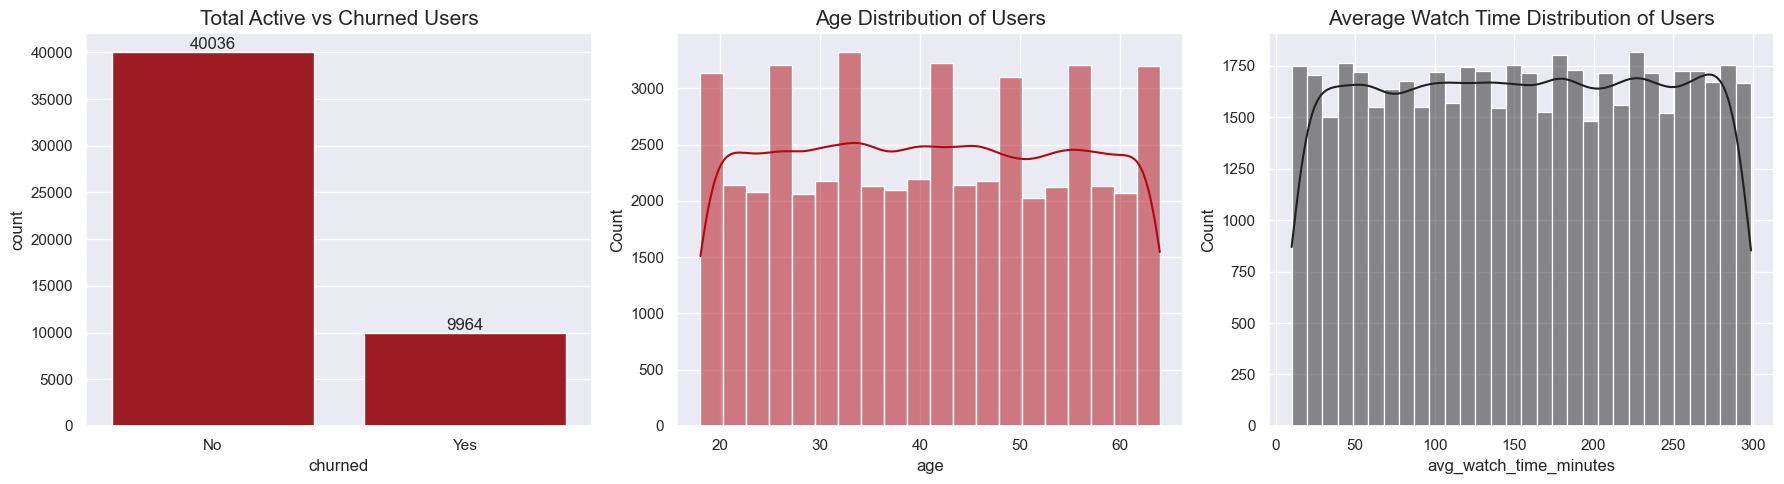

In [10]:
# creating plots to know the distribution
fig,axes=plt.subplots(1,3,figsize=(18,5))
# showing total active vs churned users
sns.countplot(data=df,x='churned',ax=axes[0])
axes[0].set_title('Total Active vs Churned Users',fontsize=15)
axes[0].bar_label(axes[0].containers[0])

#age distribution of users
sns.histplot(data=df,x='age',ax=axes[1],bins=20,kde=True,color='#b20710')
axes[1].set_title('Age Distribution of Users',fontsize=15)

#average watch time distribution of users
sns.histplot(data=df,x='avg_watch_time_minutes',ax=axes[2],bins=30,kde=True,color='#221f1f')
axes[2].set_title('Average Watch Time Distribution of Users',fontsize=15)

plt.tight_layout()
plt.show()


## Bivariate analysis

[Text(0, 0, '1233'),
 Text(0, 0, '1251'),
 Text(0, 0, '1256'),
 Text(0, 0, '1201'),
 Text(0, 0, '1266'),
 Text(0, 0, '1269'),
 Text(0, 0, '1283'),
 Text(0, 0, '1205')]

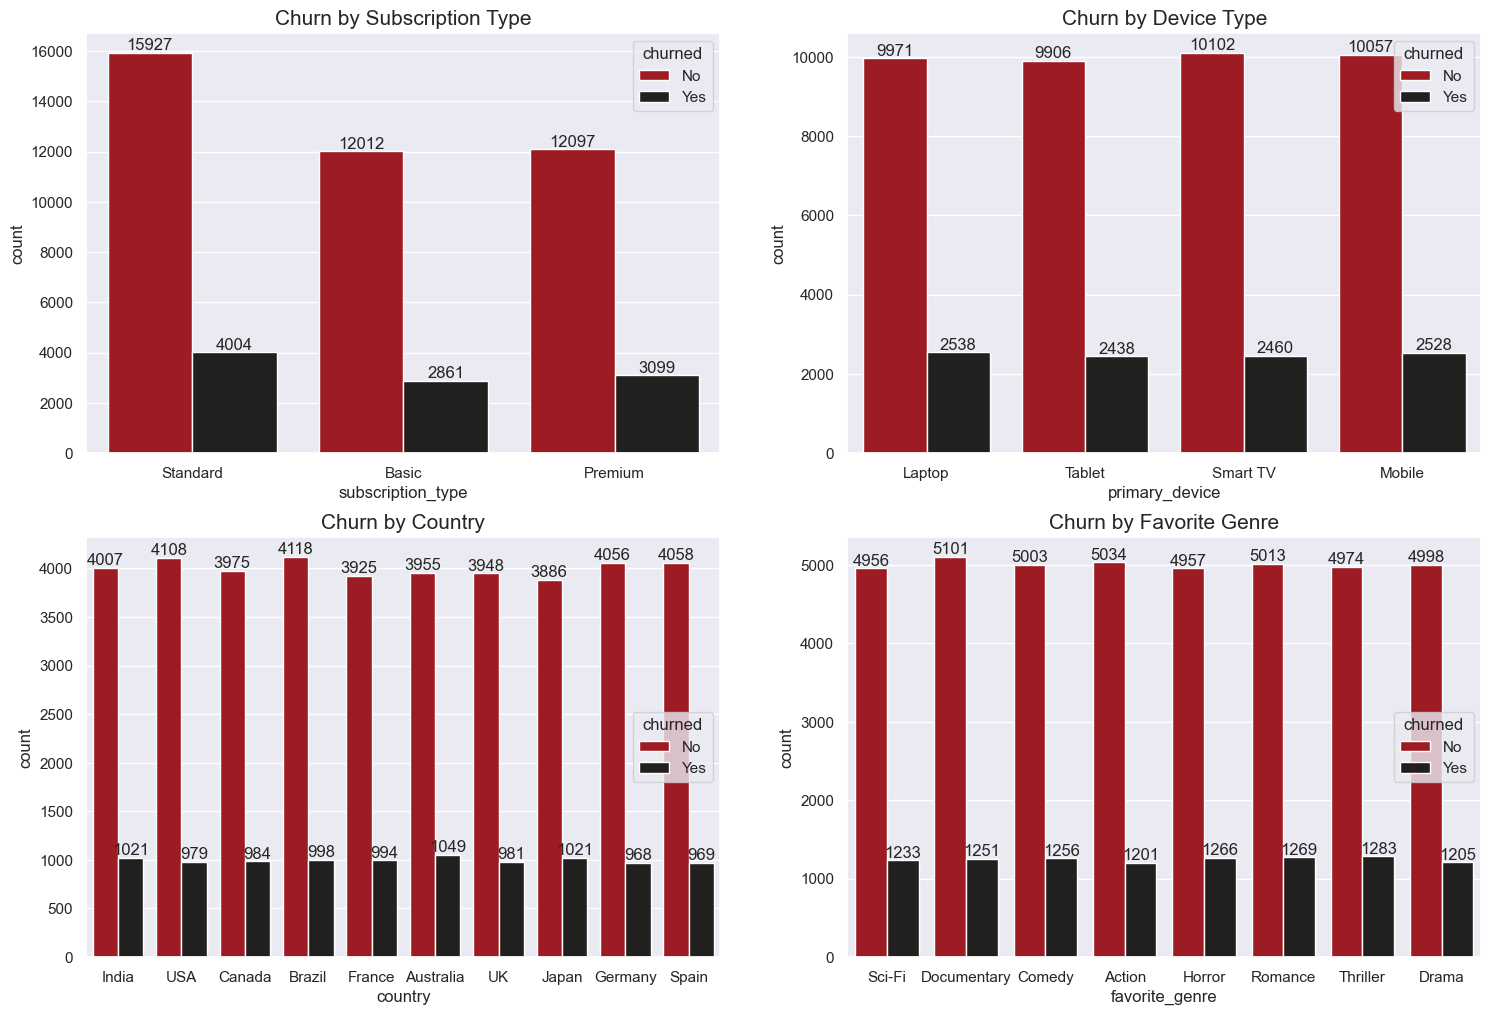

In [11]:
#Analysis of churned users based on different features
fig,axes=plt.subplots(2,2,figsize=(18,12))
#churn by subscription type
sns.countplot(data=df,x='subscription_type',hue='churned',ax=axes[0][0])
axes[0][0].set_title('Churn by Subscription Type',fontsize=15)
axes[0][0].bar_label(axes[0][0].containers[0])
axes[0][0].bar_label(axes[0][0].containers[1])

#churn by device type
sns.countplot(data=df,x='primary_device',hue='churned',ax=axes[0][1])
axes[0][1].set_title('Churn by Device Type',fontsize=15)
axes[0][1].bar_label(axes[0][1].containers[0])
axes[0][1].bar_label(axes[0][1].containers[1])

#churn by country

sns.countplot(data=df,x='country',hue='churned',ax=axes[1][0])
axes[1][0].set_title('Churn by Country',fontsize=15)
axes[1][0].bar_label(axes[1][0].containers[0])
axes[1][0].bar_label(axes[1][0].containers[1])

#Churn by favorite genre
sns.countplot(data=df,x='favorite_genre',hue='churned',ax=axes[1][1])
axes[1][1].set_title('Churn by Favorite Genre',fontsize=15)
axes[1][1].bar_label(axes[1][1].containers[0])
axes[1][1].bar_label(axes[1][1].containers[1])

In [12]:
#analysing numerical features with respect to churned users
numerical_features=df.columns[np.where(df.dtypes != 'object')]
numerical_features

Index(['age', 'account_age_months', 'monthly_fee', 'devices_used',
       'avg_watch_time_minutes', 'watch_sessions_per_week',
       'binge_watch_sessions', 'completion_rate', 'rating_given',
       'content_interactions', 'recommendation_click_rate',
       'days_since_last_login'],
      dtype='object')

Text(0.5, 1.0, 'Churned Users Based on Average Watch Time')

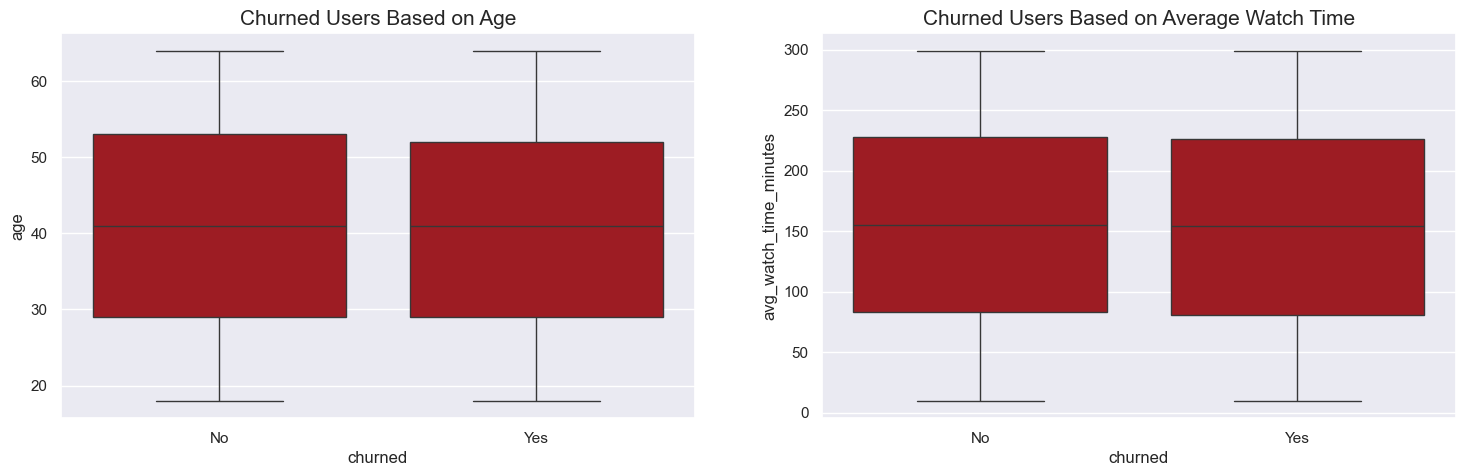

In [13]:
fig,axes=plt.subplots(1,2,figsize=(18,5))

#churned users based on age
sns.boxplot(data=df,x='churned',y='age',ax=axes[0])
axes[0].set_title('Churned Users Based on Age',fontsize=15)

#churned users based onavg_watch_time_minutes
sns.boxplot(data=df,x='churned',y='avg_watch_time_minutes',ax=axes[1])
axes[1].set_title('Churned Users Based on Average Watch Time',fontsize=15)


## Multivariate analysis


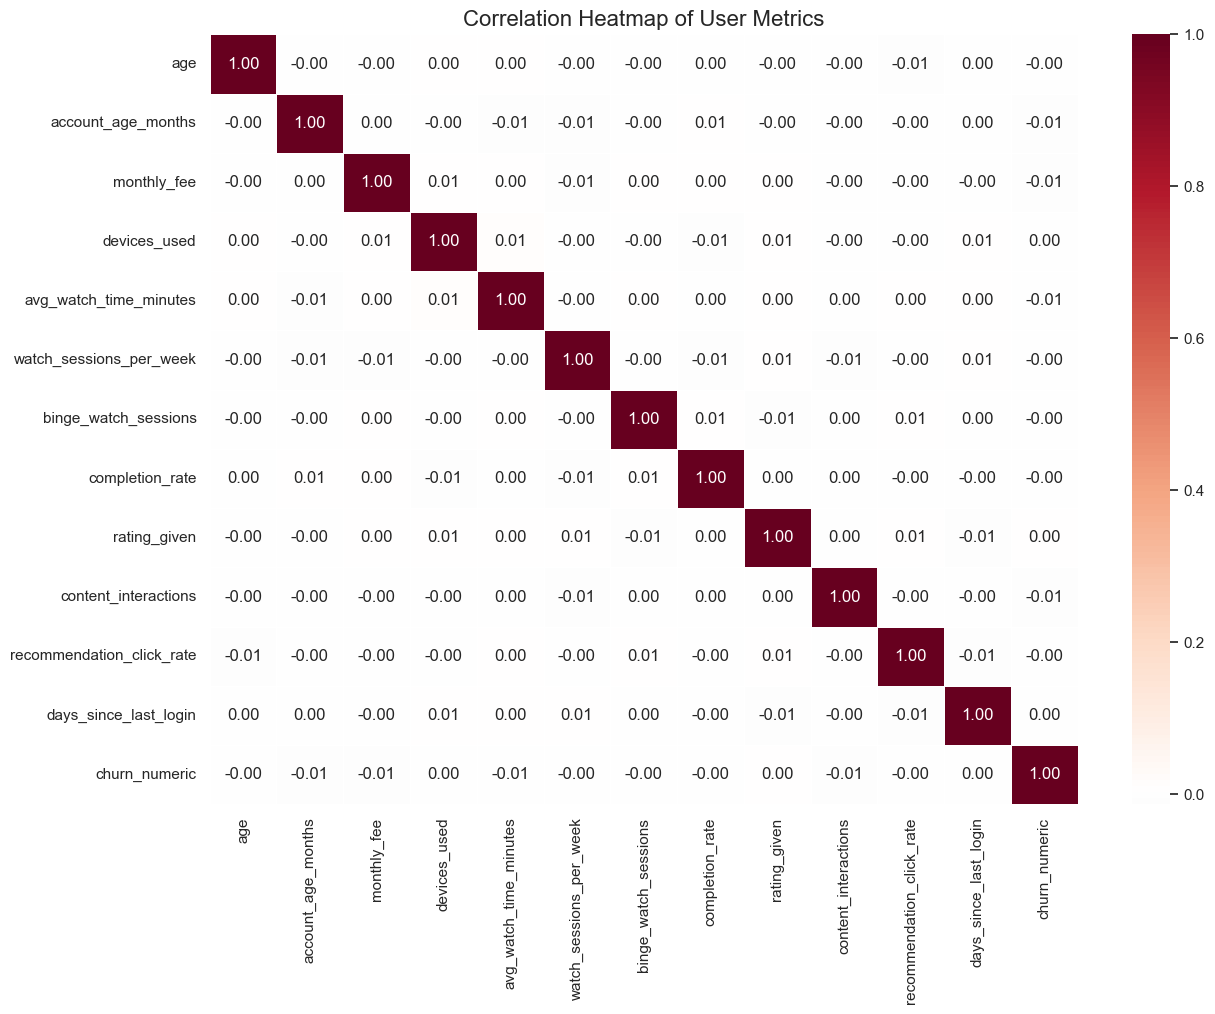

In [14]:
#making correlation heatmap
df_corr=df.copy()
df_corr['churn_numeric']=df_corr['churned'].map({'Yes':1,'No':0})
numercic_df=df_corr.select_dtypes(include=[np.number])

correlation_matrix = numercic_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="RdGy_r", center=0, linewidths=0.5)
plt.title('Correlation Heatmap of User Metrics', fontsize=16)
plt.show()


In [15]:
#some mathematical data income

# deriving Customer_Lifetime_value
df['CLV']=df['account_age_months']*df['monthly_fee']
# aggregating the data to see financical impact by subscription type

clv_summary = df.groupby('subscription_type').agg(
    Total_Users=('user_id', 'count'),
    Average_CLV=('CLV', 'mean'),
    Total_Lifetime_Revenue=('CLV', 'sum')
).round(2)

clv_summary['Average_CLV'] = clv_summary['Average_CLV'].apply(lambda x: f"${x:,.2f}")
clv_summary['Total_Lifetime_Revenue'] = clv_summary['Total_Lifetime_Revenue'].apply(lambda x: f"${x:,.2f}")

clv_summary=clv_summary.sort_values('Total_Lifetime_Revenue',ascending=False)

clv_summary

,Total_Users,Average_CLV,Total_Lifetime_Revenue
subscription_type,,,
Standard,19931,$369.41,"$7,362,733.94"
Premium,15196,$368.95,"$5,606,623.73"
Basic,14873,$366.05,"$5,444,215.33"


In [16]:
# Ensure churn_binary is present
df['churn_binary'] = df['churned'].map({'Yes': 1, 'No': 0})

In [17]:

#analysisng based on tenure_cohort of the customers
bins=[0,12,36,60]
labels=['New','Established','Veteran']
df['tenure_cohort']=pd.cut(df['account_age_months'],bins=bins,labels=labels)

#analysis based on tenure_cohot
cohort_analysis=df.groupby('tenure_cohort').agg(
    total_user=('user_id','count'),
    Avg_CLV=('CLV','mean'),
    total_lifetime_revenue=('CLV','sum')
)

cohort_analysis['Avg_CLV']=cohort_analysis['Avg_CLV'].apply(lambda x:f"${x:,.2f}")
cohort_analysis['total_lifetime_revenue']=cohort_analysis['total_lifetime_revenue'].apply(lambda x:f"${x:,.2f}")


cohort_analysis

C:\Users\abhir\AppData\Local\Temp\ipykernel_18816\372520111.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cohort_analysis=df.groupby('tenure_cohort').agg(


,total_user,Avg_CLV,total_lifetime_revenue
tenure_cohort,,,
New,10292,$79.68,"$820,027.11"
Established,20360,$302.35,"$6,155,875.33"
Veteran,19348,$591.16,"$11,437,670.56"


In [18]:
## Extracting basic infos now

In [19]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'account_age_months',
       'subscription_type', 'monthly_fee', 'payment_method', 'primary_device',
       'devices_used', 'favorite_genre', 'avg_watch_time_minutes',
       'watch_sessions_per_week', 'binge_watch_sessions', 'completion_rate',
       'rating_given', 'content_interactions', 'recommendation_click_rate',
       'days_since_last_login', 'churned', 'CLV', 'churn_binary',
       'tenure_cohort'],
      dtype='object')

In [20]:
average_account_age=df['account_age_months'].mean()
average_account_age

np.float64(29.874)

In [21]:
#max type of subscription
df.groupby('subscription_type').count()['user_id'].head(1)

subscription_type
Basic    14873
Name: user_id, dtype: int64

In [22]:

df.columns

Index(['user_id', 'age', 'gender', 'country', 'account_age_months',
       'subscription_type', 'monthly_fee', 'payment_method', 'primary_device',
       'devices_used', 'favorite_genre', 'avg_watch_time_minutes',
       'watch_sessions_per_week', 'binge_watch_sessions', 'completion_rate',
       'rating_given', 'content_interactions', 'recommendation_click_rate',
       'days_since_last_login', 'churned', 'CLV', 'churn_binary',
       'tenure_cohort'],
      dtype='object')

In [23]:
#calculating how much a user is spending per hour depending upon its watch time in a month
df['monthly_watch_hours']=(df['avg_watch_time_minutes']/60)*30

#cost incurred by an user with each hour spending

df['Cost_incurred_per_hour']=df['monthly_fee']/df['monthly_watch_hours']
df['Cost_incurred_per_hour']=df['Cost_incurred_per_hour'].round(2)

In [24]:
df.head()

,user_id,age,gender,country,account_age_months,subscription_type,monthly_fee,payment_method,primary_device,devices_used,...,rating_given,content_interactions,recommendation_click_rate,days_since_last_login,churned,CLV,churn_binary,tenure_cohort,monthly_watch_hours,Cost_incurred_per_hour
0,U100000,56,Male,India,17,Standard,15.99,PayPal,Laptop,1,...,1.7,5,66,16,No,271.83,0,Established,110.0,0.15
1,U100001,46,Female,USA,20,Standard,12.99,PayPal,Tablet,2,...,4.6,7,78,14,No,259.80,0,Established,38.0,0.34
2,U100002,32,Other,USA,25,Basic,15.99,PayPal,Tablet,2,...,2.0,27,29,41,No,399.75,0,Established,107.5,0.15
3,U100003,60,Male,Canada,37,Standard,12.99,PayPal,Smart TV,3,...,1.2,9,23,22,No,480.63,0,Veteran,140.0,0.09
4,U100004,25,Male,Brazil,23,Premium,12.99,PayPal,Mobile,3,...,1.3,49,56,54,No,298.77,0,Established,130.5,0.10


In [25]:
#Users who pay a lot but watch very little (High Cost Per Hour) realize they are wasting money and cancel their subscription
# 2. Create ROI Value Buckets (Binning)
bins = [0, 0.10, 0.25, 0.50, 1.0, np.inf]
labels = [
    '< $0.10/hr (Great Value)', 
    '$0.10 - $0.25/hr (Good)', 
    '$0.25 - $0.50/hr (Fair)', 
    '$0.50 - $1.00/hr (Poor)', 
    '> $1.00/hr (Terrible Value)'
]
df['roi_bucket'] = pd.cut(df['Cost_incurred_per_hour'], bins=bins, labels=labels)

# 3. Analyze Churn Rate across these ROI Buckets
roi_churn = df.groupby('roi_bucket', observed=False).agg(
    Total_Users=('user_id', 'count'),
    Churn_Rate_Pct=('churn_binary', lambda x: (x.mean() * 100).round(2))
)

# 4. Analyze Average ROI by Subscription Tier
tier_roi = df.groupby('subscription_type').agg(
    Avg_Cost_Per_Hour_Watched=('Cost_incurred_per_hour', 'mean'),
    Median_Cost_Per_Hour_Watched=('Cost_incurred_per_hour','median')
).round(3)

print("--- HYPOTHESIS TEST: DOES POOR ROI DRIVE CHURN? ---")
display(roi_churn)

print("\n--- WHICH TIER IS THE BEST VALUE? ---")
display(tier_roi)




--- HYPOTHESIS TEST: DOES POOR ROI DRIVE CHURN? ---


,Total_Users,Churn_Rate_Pct
roi_bucket,,
< $0.10/hr (Great Value),11407,19.91
$0.10 - $0.25/hr (Good),23648,19.73
$0.25 - $0.50/hr (Fair),8168,20.13
$0.50 - $1.00/hr (Poor),4230,20.64
> $1.00/hr (Terrible Value),2547,20.06



--- WHICH TIER IS THE BEST VALUE? ---


,Avg_Cost_Per_Hour_Watched,Median_Cost_Per_Hour_Watched
subscription_type,,
Basic,0.293,0.16
Premium,0.290,0.16
Standard,0.293,0.16


In [26]:
final_cols = [
    'user_id', 'age', 'country', 'account_age_months', 'tenure_cohort', 
    'subscription_type', 'monthly_fee', 'CLV', 'payment_method', 'primary_device',
    'favorite_genre', 'avg_watch_time_minutes', 'monthly_watch_hours', 
    'Cost_incurred_per_hour', 'roi_bucket', 'churned', 'churn_binary'
]

df_final = df[final_cols].copy()

# 3. Export to a new CSV specifically for the dashboard
export_filename = 'netflix_powerbi_ready.csv'
df_final.to_csv(export_filename, index=False)

print(f"\nSUCCESS: Data exported to '{export_filename}'")
print(f"Final dataset shape: {df_final.shape[0]} rows, {df_final.shape[1]} columns")


SUCCESS: Data exported to 'netflix_powerbi_ready.csv'
Final dataset shape: 50000 rows, 17 columns


In [27]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'account_age_months',
       'subscription_type', 'monthly_fee', 'payment_method', 'primary_device',
       'devices_used', 'favorite_genre', 'avg_watch_time_minutes',
       'watch_sessions_per_week', 'binge_watch_sessions', 'completion_rate',
       'rating_given', 'content_interactions', 'recommendation_click_rate',
       'days_since_last_login', 'churned', 'CLV', 'churn_binary',
       'tenure_cohort', 'monthly_watch_hours', 'Cost_incurred_per_hour',
       'roi_bucket'],
      dtype='object')

In [28]:
df.head()

,user_id,age,gender,country,account_age_months,subscription_type,monthly_fee,payment_method,primary_device,devices_used,...,content_interactions,recommendation_click_rate,days_since_last_login,churned,CLV,churn_binary,tenure_cohort,monthly_watch_hours,Cost_incurred_per_hour,roi_bucket
0,U100000,56,Male,India,17,Standard,15.99,PayPal,Laptop,1,...,5,66,16,No,271.83,0,Established,110.0,0.15,$0.10 - $0.25/hr (Good)
1,U100001,46,Female,USA,20,Standard,12.99,PayPal,Tablet,2,...,7,78,14,No,259.80,0,Established,38.0,0.34,$0.25 - $0.50/hr (Fair)
2,U100002,32,Other,USA,25,Basic,15.99,PayPal,Tablet,2,...,27,29,41,No,399.75,0,Established,107.5,0.15,$0.10 - $0.25/hr (Good)
3,U100003,60,Male,Canada,37,Standard,12.99,PayPal,Smart TV,3,...,9,23,22,No,480.63,0,Veteran,140.0,0.09,< $0.10/hr (Great Value)
4,U100004,25,Male,Brazil,23,Premium,12.99,PayPal,Mobile,3,...,49,56,54,No,298.77,0,Established,130.5,0.10,< $0.10/hr (Great Value)
